<a href="https://colab.research.google.com/github/samipCDY/image_identification/blob/main/train2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
# 2. Define your dataset paths
base_dir = '/content/drive/MyDrive/CNP_dataset'
train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

In [ ]:
# 3. Pre-flight Check (Folder Names)
try:
    if os.path.exists(train_dir) and os.path.exists(test_dir):
        print("✅ Paths found.")
        train_classes = set(os.listdir(train_dir))
        test_classes = set(os.listdir(test_dir))

        # Check for mismatches
        if train_classes != test_classes:
            print("⚠️ WARNING: Folder name mismatch detected!")
            print(f"In Train but not Test: {train_classes - test_classes}")
            print(f"In Test but not Train: {test_classes - train_classes}")
            print("Please rename the folders in Google Drive to match exactly.")
        else:
            print("✅ Folder structure looks perfect. Proceeding...")
    else:
        print("❌ Error: Paths not found. Check your Drive folder structure.")
except Exception as e:
    print(f"Error checking folders: {e}")

✅ Paths found.
✅ Folder structure looks perfect. Proceeding...


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create generators with augmentation (flipping/zooming) for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nLoading Testing Data:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Loading Training Data:
Found 1971 images belonging to 5 classes.

Loading Testing Data:
Found 436 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load pre-trained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model

# Add our custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model built successfully!")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully!


In [ ]:
import numpy as np
from collections import Counter
import os

base_path = '/content/drive/MyDrive/CNP_dataset'  # ADD THIS

# Count images per class
class_counts = {}
for cls in train_generator.class_indices:
    folder = os.path.join(f'{base_path}/Train', cls)
    count = len(os.listdir(folder))
    class_counts[cls] = count
    print(f"{cls}: {count} images")

# Compute class weights to balance training
total = sum(class_counts.values())
n_classes = len(class_counts)
class_weights = {}
for cls, idx in train_generator.class_indices.items():
    class_weights[idx] = total / (n_classes * class_counts[cls])

print("\nClass weights:", class_weights)


Elephant: 400 images
Gharial: 400 images
Rhino: 412 images
TheMuggerCrocodile: 400 images
Tiger: 359 images

Class weights: {0: 0.9855, 1: 0.9855, 2: 0.9567961165048544, 3: 0.9855, 4: 1.098050139275766}


In [ ]:
# ============================================
# 🔍 Pre-Training File Validator — Run BEFORE model.fit()
# ============================================

import os
from PIL import Image

base_path = '/content/drive/MyDrive/CNP_dataset'
animals = ['Elephant', 'Gharial', 'Rhino', 'TheMuggerCrocodile', 'Tiger']

print("🔍 Validating all images before training...")
total_removed = 0

for split in ['Train', 'Test']:
    for animal in animals:
        folder = f'{base_path}/{split}/{animal}'
        if not os.path.exists(folder):
            continue
        for filename in os.listdir(folder):
            filepath = os.path.join(folder, filename)
            try:
                img = Image.open(filepath)
                img.verify()  # checks if file is valid
            except Exception:
                print(f"🗑️ Removing bad file: {filepath}")
                os.remove(filepath)
                total_removed += 1

print(f"\n✅ Validation done — {total_removed} bad files removed")
print("▶️ Safe to run training now!")

🔍 Validating all images before training...

✅ Validation done — 0 bad files removed
▶️ Safe to run training now!


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)          # helps stabilize training
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)  # L2 regularization
x = Dropout(0.5)(x)                  # increased from 0.3 to 0.5
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.4)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print('Model built successfully!')

Model built successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from PIL import Image
Image.LOAD_TRUNCATED_IMAGES = True

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=30.0,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{base_path}/Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    f'{base_path}/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/CNP_dataset/best_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

print('Training complete!')

Found 1971 images belonging to 5 classes.
Found 436 images belonging to 5 classes.
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5887 - loss: 1.8013
Epoch 1: val_accuracy improved from None to 0.92661, saving model to /content/drive/MyDrive/CNP_dataset/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/CNP_dataset/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.7270 - loss: 1.3797 - val_accuracy: 0.9266 - val_loss: 0.7938 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8764 - loss: 0.9500
Epoch 2: val_accuracy improved from 0.92661 to 0.94495, saving model to /content/drive/MyDrive/CNP_dataset/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/CNP_dataset/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8787 - loss: 0.9366 - val_accuracy: 0.9450 - val_loss: 0.7135 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8863 - loss: 0.9155
Epoch 3: val_accuracy did not improve from 0.94495
62/62 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.8965 - loss: 0.8839 - val_accuracy: 0.9266 - val_loss: 0.7094 - learning_rate: 0.0010
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9089 - loss: 0.8518
Epoch 4: val_accuracy did not improve from 0.94495
62/62 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9041 - loss: 0.8527 - val_accuracy: 0.9266 - val_loss: 0.7115 - learning_rate: 0.0010
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9255 - loss: 0.7936
Epoch 5: val_accuracy did not improve from 0.94495
62/62 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9214 - loss: 0.8117 - val_accuracy: 0.93

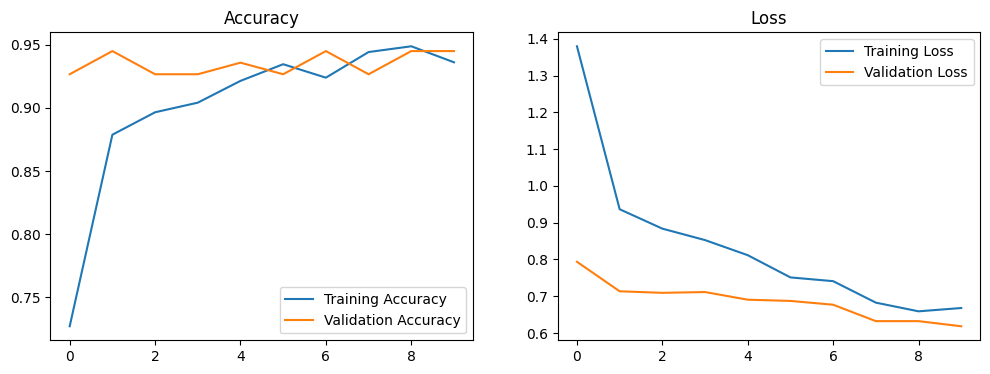

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/CNP_dataset/cnp_animal_model.h5'
model.save(save_path)
print(f"Model saved successfully at: {save_path}")

Model saved successfully at: /content/drive/MyDrive/CNP_dataset/cnp_animal_model.h5


In [ ]:
# ── Check file sizes ──
import os
h5_path = '/content/drive/MyDrive/CNP_dataset/cnp_animal_model.h5'
print(f"H5 size: {os.path.getsize(h5_path) / 1024 / 1024:.2f} MB  (expected ~55 MB)")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_types = [tf.float32]
tflite_model = converter.convert()

tflite_path = '/content/drive/MyDrive/CNP_dataset/animal_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite size: {len(tflite_model) / 1024 / 1024:.2f} MB  (expected ~13-14 MB)")


H5 size: 13.32 MB  (expected ~55 MB)
Saved artifact at '/tmp/tmp4zp4t2_9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_162')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133679494533904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494544656: TensorSpec(shape=(), dtype

In [ ]:
# Test all 5 animals
import numpy as np
from tensorflow.keras.preprocessing import image
import os

class_names = sorted(os.listdir('/content/drive/MyDrive/CNP_dataset/Train'))
train_dir = '/content/drive/MyDrive/CNP_dataset/Test'

print("=== SANITY CHECK — ALL ANIMALS ===")
for animal in class_names:
    folder = f'/content/drive/MyDrive/CNP_dataset/Test/{animal}'
    img_file = os.path.join(folder, os.listdir(folder)[0])

    img = image.load_img(img_file, target_size=(224, 224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x, verbose=0)

    predicted = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100
    status = "✅" if predicted == animal else "❌"
    print(f"{status} {animal}: predicted={predicted} ({confidence:.1f}%)")


=== SANITY CHECK — ALL ANIMALS ===
✅ Elephant: predicted=Elephant (99.9%)
✅ Gharial: predicted=Gharial (93.9%)
✅ Rhino: predicted=Rhino (99.8%)
✅ TheMuggerCrocodile: predicted=TheMuggerCrocodile (97.7%)
✅ Tiger: predicted=Tiger (100.0%)


Saving 51945560608_1cb255eb82_n.jpg to 51945560608_1cb255eb82_n.jpg


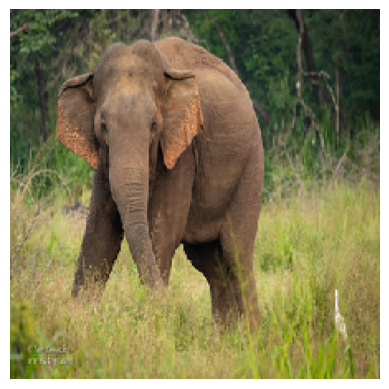

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted: Elephant (99.23%)
------------------------------


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Set the threshold (e.g., 0.80 means 80% confidence required)
CONFIDENCE_THRESHOLD = 0.80

# Upload file
uploaded = files.upload()

for fn in uploaded.keys():
    # Load and display the image
    img = image.load_img(fn, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Preprocess for prediction
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Make Prediction
    preds = model.predict(x)
    max_confidence = np.max(preds)

    if max_confidence < CONFIDENCE_THRESHOLD:
        print(f"Result: Animal not in the context / Low Confidence ({max_confidence*100:.2f}%)")
    else:
        class_names = sorted(os.listdir(train_dir))
        result = class_names[np.argmax(preds)]
        print(f"Predicted: {result} ({max_confidence*100:.2f}%)")
    print("-" * 30)

Found 436 images belonging to 5 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


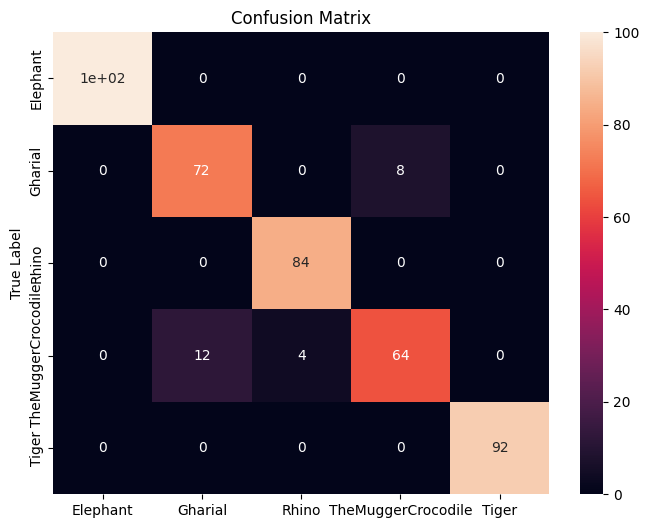

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# New generator with shuffle=False
cm_datagen = ImageDataGenerator(rescale=1./255)
test_generator = cm_datagen.flow_from_directory(
    f'{base_path}/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False        # IMPORTANT!
)

class_names = list(test_generator.class_indices.keys())

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.show()

Found 436 images belonging to 5 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


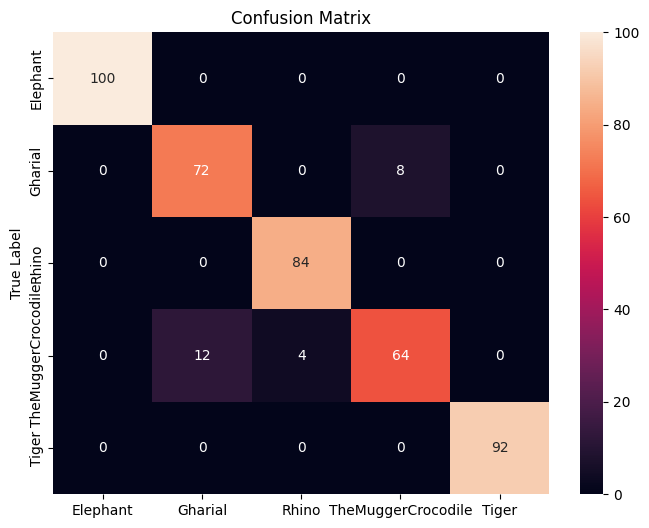

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_datagen = ImageDataGenerator(rescale=1./255)
cm_generator = cm_datagen.flow_from_directory(
    f'{base_path}/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

predictions = model.predict(cm_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = cm_generator.classes
class_names = list(cm_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
# plt.xlabel('Predicted Label')  ← removed this line
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


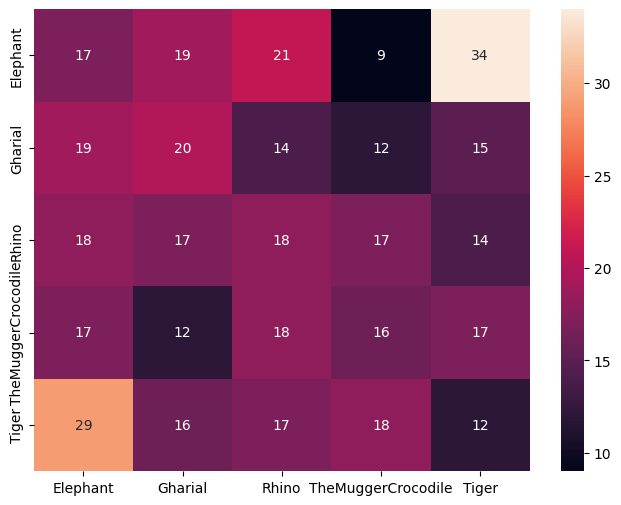

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Recreate test generator with NO shuffle
fresh_test_datagen = ImageDataGenerator(rescale=1./255)
fresh_test_generator = fresh_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/CNP_dataset/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # ← THIS IS THE KEY!
)

# Predict
Y_pred = model.predict(fresh_test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = fresh_test_generator.classes

class_names = list(fresh_test_generator.class_indices.keys())

print("=== F1 SCORE ===")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 436 images belonging to 5 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
=== F1 SCORE ===
                    precision    recall  f1-score   support

          Elephant       1.00      1.00      1.00       100
           Gharial       0.86      0.90      0.88        80
             Rhino       0.95      1.00      0.98        84
TheMuggerCrocodile       0.89      0.80      0.84        80
             Tiger       1.00      1.00      1.00        92

          accuracy                           0.94       436
         macro avg       0.94      0.94      0.94       436
      weighted avg       0.94      0.94      0.94       436



In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('/content/drive/MyDrive/CNP_dataset/animal_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Mobile model (.tflite) saved!")

Saved artifact at '/tmp/tmpq3ghipas'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_162')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133679494533904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494543504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133679494544656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336794945

In [ ]:
import tensorflow as tf
import os

# 1. Load your trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/CNP_dataset/cnp_animal_model.h5')

# 2. Convert to TFLite (Mobile optimized)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 3. Save the model file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

# 4. Create the labels file (Must match your folder names exactly)
# Order: Elephant, Gharial, Rhino, The Mugger Crocodile, Tiger
class_names = sorted(os.listdir('/content/drive/MyDrive/CNP_dataset/Train'))
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print("✅ Successfully created 'model.tflite' and 'labels.txt'")

Saved artifact at '/tmp/tmphvqyws1d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133678649965264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649964112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649964304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649964688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649963536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649964880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649963920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649963728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649965072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678649962384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336786499629

In [ ]:
# This code creates the labels.txt file automatically
import os
class_names = sorted(os.listdir('/content/drive/MyDrive/CNP_dataset/Train'))
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')
print("Successfully created labels.txt")

Successfully created labels.txt
